In [ ]:
# ============================================
# Notebook 3 - efficiency for Charming ALP
# ============================================
# This notebook studies the efficiecy for the Charming ALP model with the same analysis as in notebook 1. 
# However, unlike notebook 1, this notebook studies also the efficiency with CalRatio trigger, Muon trigger and eletron trigger.
# Six benchmarks are studied, with different masses and lifetimes. The efficiency is computed for each benchmark and each trigger, and the results are plotted as a function of pT.
# Common functions imported from notebook 1:
#   load_tree(), load_variables(), 
#   compute_DeltaR(), Compute_efficiency()
# ============================================

In [ ]:
import uproot
import awkward as ak
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os

In [ ]:
dossier = r"C:\Users\ahlam\Internship\Fichier.root\a_tt"

fichiers = {
    "ma15_ct1" : "\\Users\\ahlam\\Internship\\Fichier.root\\a_tt\\outputFiles1_ma_15_ct1.root",
    "ma15_ct10" : "\\Users\\ahlam\\Internship\\Fichier.root\\a_tt\\outputFiles1_ma_15_ct10.root",
    "ma15_ct1000" : "\\Users\\ahlam\\Internship\\Fichier.root\\a_tt\\outputFiles1_ma_15_ct1000.root",
    "ma40_ct10": "\\Users\\ahlam\\Internship\\Fichier.root\\a_tt\\outputFiles1_ma_40_ct10.root",
    "ma40_ct1000": "\\Users\\ahlam\\Internship\\Fichier.root\\a_tt\\outputFiles1_ma_40_ct1000.root",
    "ma40_ct100": "\\Users\\ahlam\\Internship\\Fichier.root\\a_tt\\outputFiles1_ma_40_ct100.root",
}

# Labels pour les plots
labels = {
    "ma15_ct1" : r"$m_a = 15\ \mathrm{GeV},\ c\tau = 1\ \mathrm{mm}$",
    "ma15_ct10" : r"$m_a = 15\ \mathrm{GeV},\ c\tau = 10\ \mathrm{mm}$",
    "ma15_ct1000": r"$m_a = 15\ \mathrm{GeV},\ c\tau = 1000\ \mathrm{mm}$",
    "ma40_ct10" : r"$m_a = 40\ \mathrm{GeV},\ c\tau = 10\ \mathrm{mm}$",
    "ma40_ct1000" : r"$m_a = 40\ \mathrm{GeV},\ c\tau = 1000\ \mathrm{mm}$",
    "ma40_ct100" : r"$m_a = 40\ \mathrm{GeV},\ c\tau = 100\ \mathrm{mm}$",
}


ctau_map = {
    "ma15_ct1": (15, 1),
    "ma15_ct10": (15, 10),
    "ma15_ct1000": (15, 1000),
    "ma40_ct10": (40, 10),
    "ma40_ct100": (40, 100),
    "ma40_ct1000": (40,1000),
}

In [ ]:
# Function to get the triggers from the Root file. It includes CalRatio triggers, Electron triggers, and Muon triggers.
# Returns a dictionary with the triggers as keys and their corresponding lists as values.

def get_triggers(filepath):

    with uproot.open(filepath) as f:
        keys = f["reco"].keys()
        triggers = [k for k in keys if "CLEANllp" in k]
        triggers_all = [k for k in keys]
        triggers_muon = [k for k in keys if "mu" in k.lower()]

        # CalRatio triggers
        triggers_calratio = [k for k in triggers if "calratio_" in k.lower() and "rmbib" not in k.lower() and "var" not in k.lower()]
        triggers_calratiormbib = [k for k in triggers if "calratiormbib" in k.lower()]
        triggers_calratiovar = [k for k in triggers if "calratiovar" in k.lower()]
         
        # Electron triggers
        triggers_lhmedium = [k for k in triggers_all if "lhmedium" in k.lower() and k.startswith("trigPassed_HLT_")]
        triggers_lhtight = [k for k in triggers_all if "lhtight" in k.lower() and k.startswith("trigPassed_HLT_")]
        triggers_lhloose = [k for k in triggers_all if "lhloose" in k.lower() and k.startswith("trigPassed_HLT_")]
        triggers_etcut = [k for k in triggers_all if "etcut" in k.lower() and k.startswith("trigPassed_HLT_")]
        
        # Muon triggers 
        triggers_iloose = [k for k in triggers_muon if "iloose_l1mu15" in k.lower() and k.startswith("trigPassed_HLT_")]
        triggers_ivarmedium = [k for k in triggers_muon if "ivarmedium" in k.lower() and k.startswith("trigPassed_HLT_")]
        triggers_0eta105 = [k for k in triggers_muon if "0eta105" in k.lower() and k.startswith("trigPassed_HLT_")]
        triggers_muon40 = [k for k in triggers_muon if "mu40" in k.lower() and k.startswith("trigPassed_HLT_")]
        triggers_muon50 = [k for k in triggers_muon if "mu50" in k.lower() and k.startswith("trigPassed_HLT_")]

    return dict(
        triggers_calratio = triggers_calratio,
        triggers_calratiormbib = triggers_calratiormbib,
        triggers_calratiovar = triggers_calratiovar,
        triggers_lhmedium = triggers_lhmedium,
        triggers_lhtight = triggers_lhtight,
        triggers_lhloose = triggers_lhloose,
        triggers_etcut = triggers_etcut,
        triggers_iloose = triggers_iloose,
        triggers_ivarmedium = triggers_ivarmedium,
        triggers_0eta105 = triggers_0eta105,
        triggers_muon40 = triggers_muon40,
        triggers_muon50 = triggers_muon50,
    )


# Function to load the particle level and reco trees from a Root file. It returns the two trees as uproot arrays.
def load_tree(filepath):
    f= uproot.open(filepath)
    return f["particleLevel"], f["reco"]


## Functions

In [23]:
# Function to load the variables from the truth and reco trees. It returns a pandas DataFrame with the relevant variables.
def load_variables(tree_truth, tree_reco,
                   triggers_calratio, triggers_calratiormbib, triggers_calratiovar,
                   triggers_lhmedium, triggers_lhtight, triggers_lhloose, triggers_etcut,
                   triggers_iloose, triggers_ivarmedium, triggers_0eta105,
                   triggers_muon40, triggers_muon50):
    


     # Loanding inportant variable in Truth tree

    evt_truth = ak.to_numpy(tree_truth["eventNumber"].array(library="ak"))
    evt_reco = ak.to_numpy(tree_reco["eventNumber"].array(library="ak"))

    pt_raw = tree_truth["truth_alp_pt"].array(library="ak")
    eta_raw = tree_truth["truth_alp_eta"].array(library="ak")
    phi_raw = tree_truth["truth_alp_phi"].array(library="ak")
    Lx_raw = tree_truth["truth_alp_decayVtxX"].array(library="ak")
    Ly_raw = tree_truth["truth_alp_decayVtxY"].array(library="ak")
    Lz_raw = tree_truth["truth_alp_decayVtxZ"].array(library="ak")

    Lxy_all = np.sqrt(Lx_raw**2 + Ly_raw**2) / 1000.0
    Lz_all = np.abs(Lz_raw) / 1000.0
    eta_all = np.abs(eta_raw)

    # Coupures géométriques
    in_barrel_all = (eta_all < 1.4) & (Lxy_all > 1.5) & (Lxy_all < 3.9)
    in_endcap_all = (eta_all > 1.4) & (Lz_all  > 3.5) & (Lz_all  < 6.0)
    in_calo_alp = in_barrel_all | in_endcap_all

    # ALP in the Calo (for CalRatio)
    
    pt_mask = ak.where(in_calo_alp, pt_raw, 0.0)
    idx_max = ak.argmax(pt_mask, axis=1, keepdims=True)

    pt = ak.to_numpy(ak.fill_none(ak.max(pt_mask, axis=1), 0.0)) / 1000.0
    eta = ak.to_numpy(ak.fill_none(ak.firsts(eta_raw[idx_max], axis=1), 0.0))
    phi = ak.to_numpy(ak.fill_none(ak.firsts(phi_raw[idx_max], axis=1), 0.0))
    Lx = ak.to_numpy(ak.fill_none(ak.firsts(Lx_raw[idx_max], axis=1), 0.0))
    Ly = ak.to_numpy(ak.fill_none(ak.firsts(Ly_raw[idx_max], axis=1), 0.0))
    Lz = ak.to_numpy(ak.fill_none(ak.firsts(Lz_raw[idx_max], axis=1), 0.0))

    Lxy = np.sqrt(Lx**2 + Ly**2) / 1000.0
    Lz = np.abs(Lz) / 1000.0

    # pT brut de l'ALP leading (sans coupure in_calo)
    idx_max_raw = ak.argmax(pt_raw, axis=1, keepdims=True)
    pt_alp_raw  = ak.to_numpy(ak.fill_none(ak.max(pt_raw, axis=1), 0.0)) / 1000.0
    eta_alp_raw = ak.to_numpy(ak.fill_none(ak.firsts(eta_raw[idx_max_raw], axis=1), 0.0))

    df_truth = pd.DataFrame({
        "eventNumber" : evt_truth,
        "pt"          : pt,          # pT ALP in the calo (CalRatio)
        "pt_alp_raw"  : pt_alp_raw,  # pT brut ALP leading (kinematical)
        "eta_alp_raw" : eta_alp_raw, # eta brut ALP leading
        "eta" : eta,
        "phi" : phi,
        "Lxy" : Lxy,
        "Lz" : Lz,
    })

    all_triggers= (triggers_calratio + triggers_calratiormbib + triggers_calratiovar +
                    triggers_lhmedium + triggers_lhtight + triggers_lhloose + triggers_etcut +
                    triggers_iloose + triggers_ivarmedium + triggers_0eta105 +
                    triggers_muon40 + triggers_muon50)

    df_reco = pd.DataFrame({"eventNumber": evt_reco})
    for trig in all_triggers:
        arr = tree_reco[trig].array(library="ak")
        if arr.ndim == 1:
            df_reco[trig]= ak.to_numpy(arr).astype(bool)
        else:
            df_reco[trig]= ak.to_numpy(ak.any(arr, axis=1)).astype(bool)

    # Additional variables 
    extra_cols = [
        "pass_charmingALP_ttbar_ALP_semilep_NOSYS",
        "pass_DisplacedTop_Hss_NOSYS",
        "el_pt_NOSYS",
        "mu_pt_NOSYS",
        "el_select_loose_NOSYS",
        "el_select_tight_NOSYS",
        "mu_select_loose_NOSYS",
        "mu_select_tight_NOSYS",
        "met_met_NOSYS",
    ]
    for col in extra_cols:
        try:
            arr = tree_reco[col].array(library="ak")
            if arr.ndim == 1:
                df_reco[col] = ak.to_numpy(arr)
            else:
                df_reco[col] = ak.to_numpy(ak.fill_none(ak.max(arr, axis=1), 0.0))
        except Exception:
            print(f"columns not founding , ignorée : {col}")

    df = pd.merge(df_truth, df_reco, on="eventNumber", how="inner")
    df["pass_any_trig"] = df[all_triggers].any(axis=1)
    df["in_barrel"] = (np.abs(df["eta"]) < 1.4) & (df["Lxy"] > 1.5) & (df["Lxy"] < 3.9)
    df["in_endcap"] = (np.abs(df["eta"]) > 1.4) & (df["Lz"]  > 3.5) & (df["Lz"]  < 6.0)
    df["in_calo"] = df["in_barrel"] | df["in_endcap"]

    return df

In [24]:
# Function to compute the DeltaR between the ALP and the reco jets. It returns a pandas DataFrame with a new column "matched_jet" indicating whether the ALP is matched 
# to a reco jet within a specified DeltaR cut.
def compute_DeltaR(df, tree_reco, dR_cut=0.2):
    
    jet_eta = tree_reco["EMTopoJet_eta"].array(library="ak")
    jet_phi = tree_reco["EMTopoJet_phi"].array(library="ak")
    evt_reco = ak.to_numpy(tree_reco["eventNumber"].array(library="ak"))

    evt_to_idx = {evt: idx for idx, evt in enumerate(evt_reco)}
    llp_eta = df["eta"].to_numpy()
    llp_phi = df["phi"].to_numpy()

    matched = []
    for i in range(len(df)):
        evt = df["eventNumber"].iloc[i]
        reco_idx = evt_to_idx.get(evt, -1)

        if reco_idx == -1 or len(jet_eta[reco_idx]) == 0:
            matched.append(False)
            continue

        deta = jet_eta[reco_idx] - llp_eta[i]
        dphi = jet_phi[reco_idx] - llp_phi[i]
        dphi = (dphi + np.pi) % (2 * np.pi) - np.pi
        dR = np.sqrt(deta**2 + dphi**2)
        matched.append(bool(ak.min(dR) < dR_cut))

    df = df.copy()
    df["matched_jet"] = matched
    return df

In [ ]:
def compute_efficiency(df, variable, bins, trigger_list, mask=None):
    
    calo_mask = df["in_calo"]
    if mask is not None:
        calo_mask = calo_mask & mask

    denom_mask = calo_mask & df["matched_jet"]
    
    # Utilise trigger_list au lieu de pass_any_trig
    trigger_list = [t for t in trigger_list if t in df.columns]
    pass_trig = df[trigger_list].any(axis=1)
    num_mask = denom_mask & pass_trig

    h_before,_ = np.histogram(df.loc[denom_mask, variable], bins=bins)
    h_after,_  = np.histogram(df.loc[num_mask, variable], bins=bins)

    eff = np.divide(h_after, h_before, out=np.zeros_like(h_after, dtype=float), where=h_before > 0)
    err = np.sqrt(np.divide(eff * (1 - eff), h_before, out=np.zeros_like(eff), where=h_before > 0))

    return eff, err, h_before, h_after

In [26]:
# Function to compute the global efficiency for a given set of triggers. It returns the efficiency, its error, the number of events passing the triggers, and the total number of events.
def compute_global_efficiency(df, trigger_list, family_name, denom_mask=None):
    trigger_list = [t for t in trigger_list if t in df.columns]
    if len(trigger_list) == 0:
        print(f"{family_name}: None trigger found in  df.")
        return None

    if denom_mask is None:
        denom_mask = pd.Series([True]*len(df), index=df.index)

    df_denom = df[denom_mask]
    N_total = len(df_denom)
    fires_trigger = df_denom[trigger_list].any(axis=1)
    N_pass= fires_trigger.sum()

    eff= N_pass/ N_total if N_total > 0 else 0
    err= np.sqrt(eff*(1 - eff) / N_total) if N_total > 0 else 0

    print(f"{family_name:10s} | ε = {eff:.4f} ± {err:.4f} ({N_pass}/{N_total} events)")
    return eff, err, N_pass, N_total


In [ ]:
filepath = r"C:\Users\ahlam\Internship\Fichier.root\a_tt\outputFiles1_ma_40_ct100.root"
trigger_kwargs = get_triggers(filepath)

tree_truth, tree_reco = load_tree(filepath)
df = load_variables(tree_truth, tree_reco, **trigger_kwargs)
df = compute_DeltaR(df, tree_reco, dR_cut=0.2)

dfs = {}
nom = "ma15_ct1"
dfs[nom] = df

print(f"Charged event: {len(df)}")
print(f"in_calo : {df['in_calo'].mean():.3f}")
print(f"matched_jet  : {df['matched_jet'].mean():.3f}")

n_in_calo = df["in_calo"].sum()
print(f"in_calo events: {n_in_calo}")
print(f"Fraction in calo: {n_in_calo / len(df):.3%}")

n_matched= df["matched_jet"].sum()
print(f"matched_jet events: {n_matched}")

Charged event: 20000
in_calo : 0.018
matched_jet  : 0.482
in_calo events: 367
Fraction in calo: 1.835%
matched_jet events: 9636


In [28]:
pt_bins = np.linspace(0, 500, 26) # for pt CalRatio
pt_raw_bins = np.linspace(0, 500, 26)  # for pt_alp_raw
Lxy_bins = np.linspace(0, 5.0, 26)
Lz_bins = np.linspace(0, 7.0, 26)
lep_pt_bins = np.linspace(0, 200, 21)


In [29]:
resultats = {}
dfs={}
trigger_kwargs_dict = {}

for nom, filepath in fichiers.items():
    print(f"\n{'='*60}")
    print(f"=== Traitement : {nom} ===")
    print(f"{'='*60}")

    trigger_kwargs = get_triggers(filepath)
    trigger_kwargs_dict[nom] = trigger_kwargs

    trig_calratio_all = (trigger_kwargs["triggers_calratio"] + trigger_kwargs["triggers_calratiormbib"] + trigger_kwargs["triggers_calratiovar"])
    trig_electron_all = (trigger_kwargs["triggers_lhmedium"] + trigger_kwargs["triggers_lhtight"] + trigger_kwargs["triggers_lhloose"] + trigger_kwargs["triggers_etcut"])
    trig_muon_all = (trigger_kwargs["triggers_iloose"] +
                         trigger_kwargs["triggers_ivarmedium"] +
                         trigger_kwargs["triggers_0eta105"] +
                         trigger_kwargs["triggers_muon40"] +
                         trigger_kwargs["triggers_muon50"])

    tree_truth, tree_reco = load_tree(filepath)
    df = load_variables(tree_truth, tree_reco,**trigger_kwargs)
    df = compute_DeltaR(df, tree_reco, dR_cut=0.2)
    dfs[nom] = df

    print(f"Événements chargés : {len(df)}")
    print(f"in_calo : {df['in_calo'].mean():.3f}")
    print(f"matched_jet : {df['matched_jet'].mean():.3f}")

    if "pass_charmingALP_ttbar_ALP_semilep_NOSYS" in df.columns:
        n_charm = df["pass_charmingALP_ttbar_ALP_semilep_NOSYS"].sum()
        print(f"pass_charmingALP   : {n_charm}/{len(df)} ({n_charm/len(df):.3f})")

    print(f"\n--- Efficacités globales ({nom}) ---")
    eff_cr, err_cr, n_cr, N_cr = compute_global_efficiency(df, trig_calratio_all,"CalRatio",
                                                        denom_mask=df["in_calo"] & df["matched_jet"])
    eff_el, err_el, n_el, N_el = compute_global_efficiency(df, trig_electron_all,"Electron")
    eff_mu, err_mu, n_mu, N_mu = compute_global_efficiency(df, trig_muon_all, "Muon")

    trig_all = trig_calratio_all + trig_electron_all + trig_muon_all
    trig_all = [t for t in trig_all if t in df.columns]
    fires_or = df[trig_all].any(axis=1)
    eff_or = fires_or.sum() / len(df)
    err_or = np.sqrt(eff_or * (1 - eff_or) / len(df))
    print(f"{'OR':10s} | ε = {eff_or:.4f} ± {err_or:.4f}  ({fires_or.sum()}/{len(df)} events)")

    resultats[nom] = {
        "eff_cr" : eff_cr, "err_cr" : err_cr,
        "eff_el" : eff_el, "err_el" : err_el,
        "eff_mu" : eff_mu, "err_mu" : err_mu,
        "eff_or" : eff_or, "err_or" : err_or,
        "in_calo" : df["in_calo"].mean(),
        "matched_jet" : df["matched_jet"].mean(),
    }

print("\n" + "="*80)
print(f"{'Benchmark':<20} {'CalRatio':>15} {'Electron':>15} {'Muon':>15} {'OR':>15}")
print("="*80)
for nom, r in resultats.items():
    print(f"{nom:<20} "
          f"{r['eff_cr']:.3f}±{r['err_cr']:.3f}"
          f"{r['eff_el']:.3f}±{r['err_el']:.3f}"
          f"{r['eff_mu']:.3f}±{r['err_mu']:.3f}"
          f"{r['eff_or']:.3f}±{r['err_or']:.3f}")



=== Traitement : ma15_ct1 ===
Événements chargés : 30000
in_calo : 0.000
matched_jet : 0.790
pass_charmingALP   : 10891/30000 (0.363)

--- Efficacités globales (ma15_ct1) ---
CalRatio   | ε = 0.0000 ± 0.0000 (0/0 events)
Electron   | ε = 0.2807 ± 0.0026 (8420/30000 events)
Muon       | ε = 0.2896 ± 0.0026 (8689/30000 events)
OR         | ε = 0.5678 ± 0.0029  (17035/30000 events)

=== Traitement : ma15_ct10 ===
Événements chargés : 30000
in_calo : 0.000
matched_jet : 0.794
pass_charmingALP   : 10772/30000 (0.359)

--- Efficacités globales (ma15_ct10) ---
CalRatio   | ε = 0.0000 ± 0.0000 (0/0 events)
Electron   | ε = 0.2754 ± 0.0026 (8262/30000 events)
Muon       | ε = 0.2898 ± 0.0026 (8695/30000 events)
OR         | ε = 0.5614 ± 0.0029  (16842/30000 events)

=== Traitement : ma15_ct1000 ===
Événements chargés : 20000
in_calo : 0.199
matched_jet : 0.372
pass_charmingALP   : 6890/20000 (0.344)

--- Efficacités globales (ma15_ct1000) ---
CalRatio   | ε = 0.0000 ± 0.0000 (0/3520 events)
El

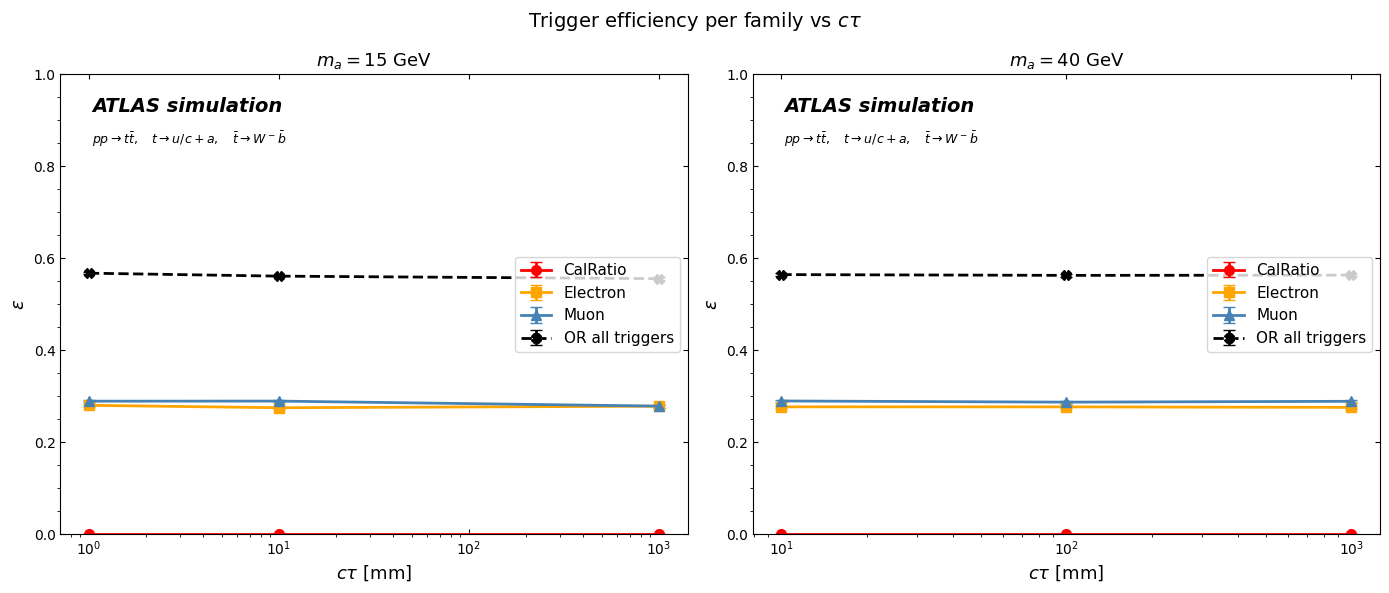

Figure saved: eff_families_vs_ctau.png


In [ ]:
# This function plots the trigger efficiency for different families (CalRatio, Electron, Muon, OR) as a function of c*tau for two different masses (15 GeV and 40 GeV). 
# It creates a figure with two subplots, one for each mass, and saves the figure as "eff_families_vs_ctau.png".
def plot_eff_families_vs_ctau(resultats, ctau_map):

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.patch.set_facecolor("white")

    for ma, ax in zip([15, 40], axes):
        ax.set_facecolor("white")

        points = {k: v for k, v in ctau_map.items() if v[0] == ma}
        ctau_vals = sorted([v[1] for v in points.values()])
        noms = sorted(points.keys(), key=lambda k: ctau_map[k][1])

        ax.errorbar(ctau_vals, [resultats[n]["eff_cr"] for n in noms],
                    yerr=[resultats[n]["err_cr"] for n in noms],
                    marker="o", linestyle="-", color="red",
                    capsize=4, linewidth=2, markersize=7, label="CalRatio")
        ax.errorbar(ctau_vals, [resultats[n]["eff_el"] for n in noms],
                    yerr=[resultats[n]["err_el"] for n in noms],
                    marker="s", linestyle="-", color="orange",
                    capsize=4, linewidth=2, markersize=7, label="Electron")
        ax.errorbar(ctau_vals, [resultats[n]["eff_mu"] for n in noms],
                    yerr=[resultats[n]["err_mu"] for n in noms],
                    marker="^", linestyle="-", color="steelblue",
                    capsize=4, linewidth=2, markersize=7, label="Muon")
        ax.errorbar(ctau_vals, [resultats[n]["eff_or"] for n in noms],
                    yerr=[resultats[n]["err_or"] for n in noms],
                    marker="X", linestyle="--", color="black",
                    capsize=4, linewidth=2, markersize=7, label="OR all triggers")

        ax.set_xscale("log")
        ax.set_xlabel(r"$c\tau$ [mm]", fontsize=13)
        ax.set_ylabel(r"$\varepsilon$", fontsize=13)
        ax.set_ylim(0, 1.0)
        ax.set_title(rf"$m_a = {ma}\ \mathrm{{GeV}}$", fontsize=13)
        ax.legend(fontsize=11, loc="center right")
        ax.minorticks_on()
        ax.tick_params(direction="in", top=True, right=True)
        ax.tick_params(direction="in", top=True, right=True)
        ax.text(0.05, 0.95, "ATLAS simulation", transform=ax.transAxes,
        fontsize=14, fontweight="bold", style="italic",
        verticalalignment="top")
        ax.text(0.05, 0.88,
        rf"$ pp \to t\bar{{t}}, \quad t \to u/c + a, \quad \bar{{t}} \to W^-\bar{{b}}$",
        transform=ax.transAxes, fontsize=9,
        verticalalignment="top")
    plt.suptitle(r"Trigger efficiency per family vs $c\tau$", fontsize=14)
    plt.tight_layout()
    plt.savefig("eff_families_vs_ctau.png", dpi=300,
                bbox_inches="tight", facecolor="white")
    plt.show()
    print("Figure saved: eff_families_vs_ctau.png")


plot_eff_families_vs_ctau(resultats, ctau_map)


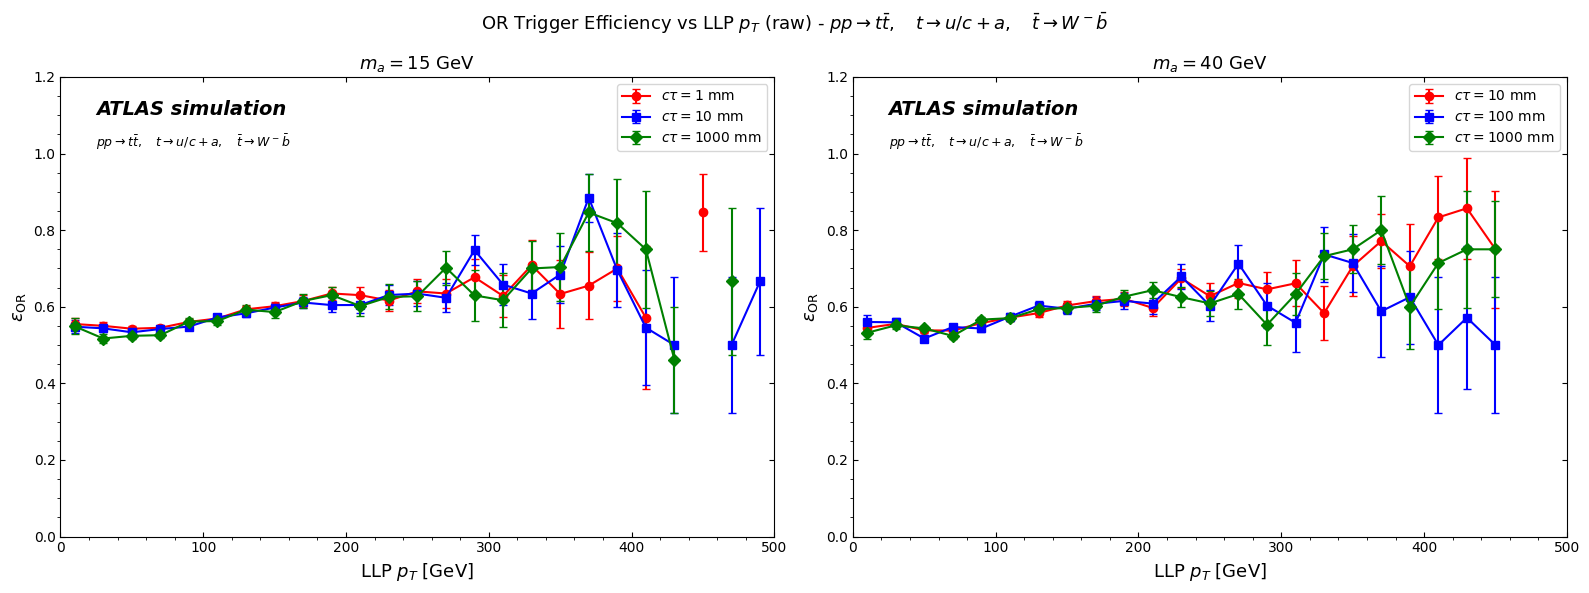

Figure saved: eff_OR_vs_pt_raw.png


In [ ]:
# This function plots the OR trigger efficiency as a function of the raw pT of the ALP for two different masses (15 GeV and 40 GeV).
def plot_eff_OR_vs_pt_raw(dfs, trigger_kwargs_dict, pt_raw_bins, ctau_map):
    """
    Trace l'efficacité OR en fonction du pT brut de l'ALP
    (sans coupure in_calo): un plot pour ma=15, un pour ma=40.
    """
    centers = 0.5 * (pt_raw_bins[:-1] + pt_raw_bins[1:])
    colors = ["red", "blue", "green", "orange", "purple", "black"]
    markers = ["o", "s", "D", "^", "v", "X"]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.patch.set_facecolor("white")

    for ma, ax in zip([15, 40], axes):
        ax.set_facecolor("white")

        points = {k: v for k, v in ctau_map.items() if v[0] == ma}
        noms = sorted(points.keys(), key=lambda k: ctau_map[k][1])

        for i, nom in enumerate(noms):
            df_tmp = dfs[nom]
            trigger_kwargs = trigger_kwargs_dict[nom]
            ctau = ctau_map[nom][1]

            trig_all = (trigger_kwargs["triggers_calratio"] +
                        trigger_kwargs["triggers_calratiormbib"] +
                        trigger_kwargs["triggers_calratiovar"] +
                        trigger_kwargs["triggers_lhmedium"] +
                        trigger_kwargs["triggers_lhtight"] +
                        trigger_kwargs["triggers_lhloose"] +
                        trigger_kwargs["triggers_etcut"] +
                        trigger_kwargs["triggers_iloose"] +
                        trigger_kwargs["triggers_ivarmedium"] +
                        trigger_kwargs["triggers_0eta105"] +
                        trigger_kwargs["triggers_muon40"] +
                        trigger_kwargs["triggers_muon50"])
            trig_all = [t for t in trig_all if t in df_tmp.columns]

            fires_or = df_tmp[trig_all].any(axis=1)

            h_total,_ = np.histogram(df_tmp["pt_alp_raw"], bins=pt_raw_bins)
            h_pass, _ = np.histogram(df_tmp.loc[fires_or, "pt_alp_raw"], bins=pt_raw_bins)

            eff = np.divide(h_pass, h_total,
                            out=np.zeros_like(h_total, dtype=float),
                            where=h_total > 0)
            err = np.sqrt(np.divide(eff*(1 - eff), h_total,
                                    out=np.zeros_like(eff),
                                    where=h_total> 0))

            eff = np.where(h_total <= 5, np.nan, eff)
            err = np.where(h_total <= 5, np.nan, err)

            ax.errorbar(centers, eff, yerr=err,
                        marker=markers[i % len(markers)],
                        linestyle="-", color=colors[i % len(colors)],
                        capsize=3, linewidth=1.5, markersize=6,
                        label=rf"$c\tau = {ctau}$ mm")

        ax.set_xlabel(r"LLP $p_T$ [GeV]", fontsize=13)
        ax.set_ylabel(r"$\varepsilon_{\text{OR}}$", fontsize=13)
        ax.set_ylim(0, 1.2)
        ax.set_xlim(pt_raw_bins[0], pt_raw_bins[-1])
        ax.set_title(rf"$m_a = {ma}\ \mathrm{{GeV}}$", fontsize=13)
        ax.legend(fontsize=10, loc="upper right")
        ax.minorticks_on()
        ax.tick_params(direction="in", top=True, right=True)
        ax.text(0.05, 0.95, "ATLAS simulation", transform=ax.transAxes,
        fontsize=14, fontweight="bold", style="italic",
        verticalalignment="top")
        ax.text(0.05, 0.88,
        rf"$ pp \to t\bar{{t}}, \quad t \to u/c + a, \quad \bar{{t}} \to W^-\bar{{b}}$",
        transform=ax.transAxes, fontsize=9,
        verticalalignment="top")

    plt.suptitle(r"OR Trigger Efficiency vs LLP $p_T$ (raw) - $pp \to t\bar{{t}}, \quad t \to u/c + a, \quad \bar{{t}} \to W^-\bar{{b}}$",
                 fontsize=13)
    plt.tight_layout()
    plt.savefig("eff_OR_vs_pt_raw.png", dpi=300,
                bbox_inches="tight", facecolor="white")
    plt.show()
    print("Figure saved: eff_OR_vs_pt_raw.png")


plot_eff_OR_vs_pt_raw(dfs, trigger_kwargs_dict, pt_raw_bins, ctau_map)

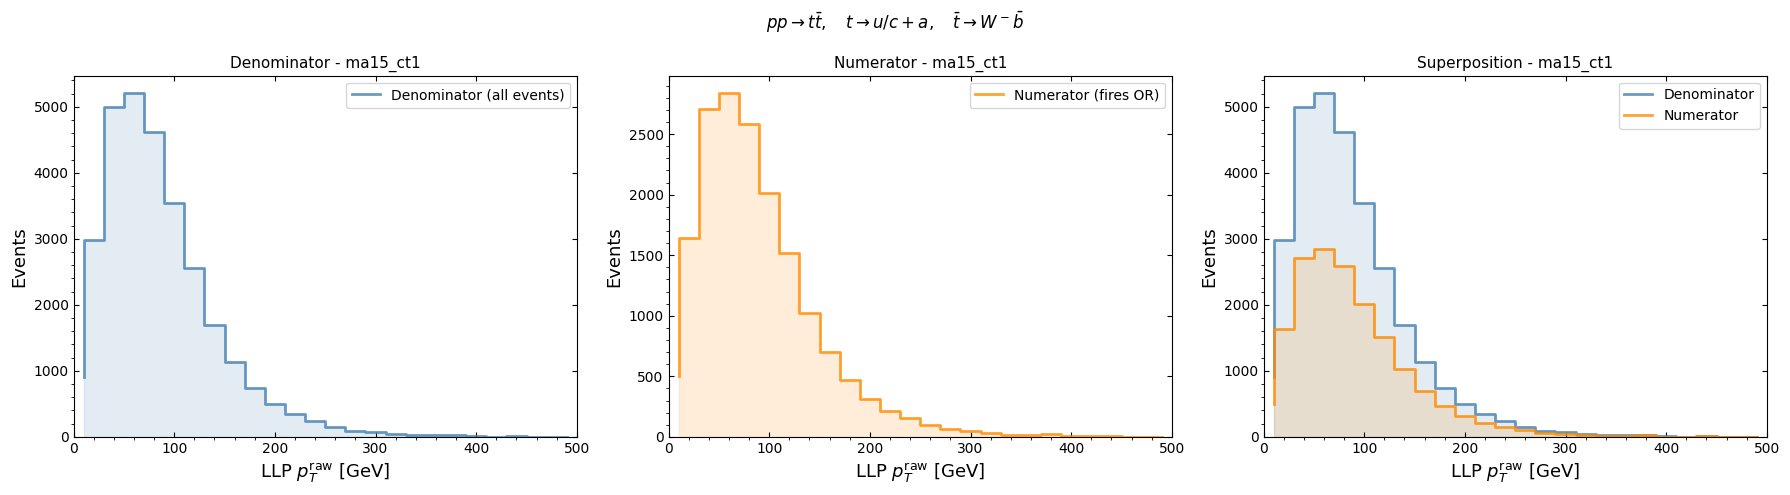

Figure saved:num_denom_vs_pt_raw_ma15_ct1.png


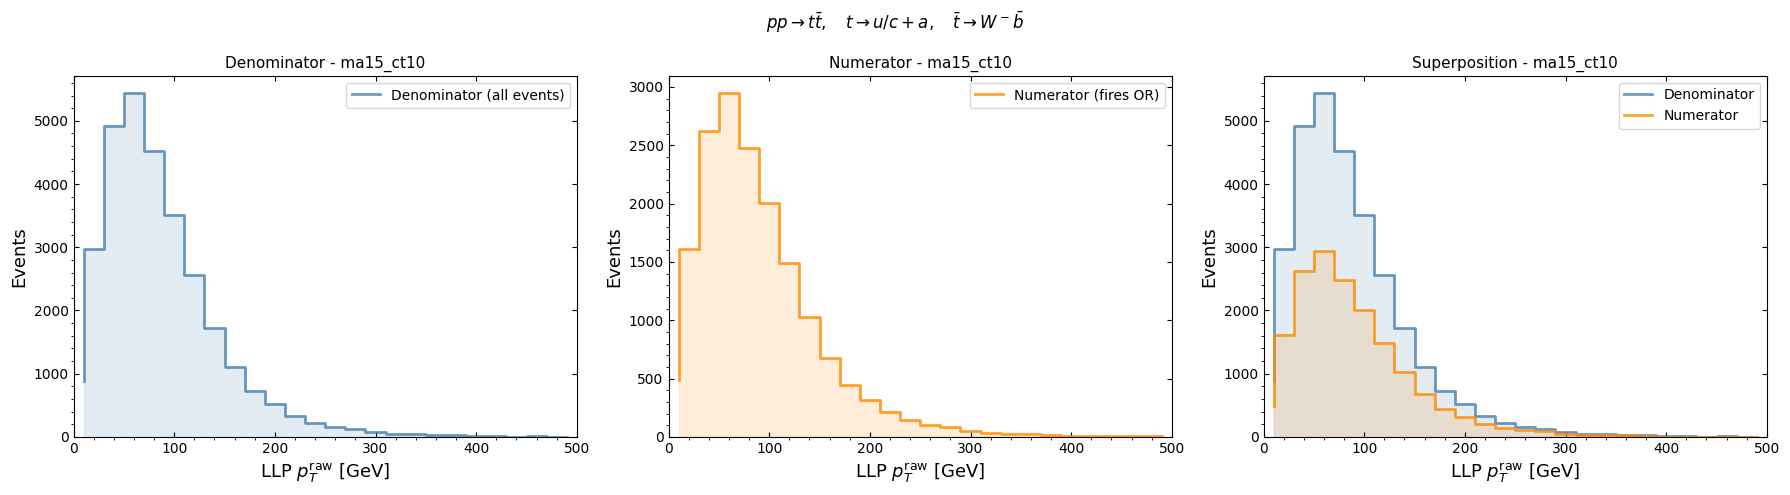

Figure saved:num_denom_vs_pt_raw_ma15_ct10.png


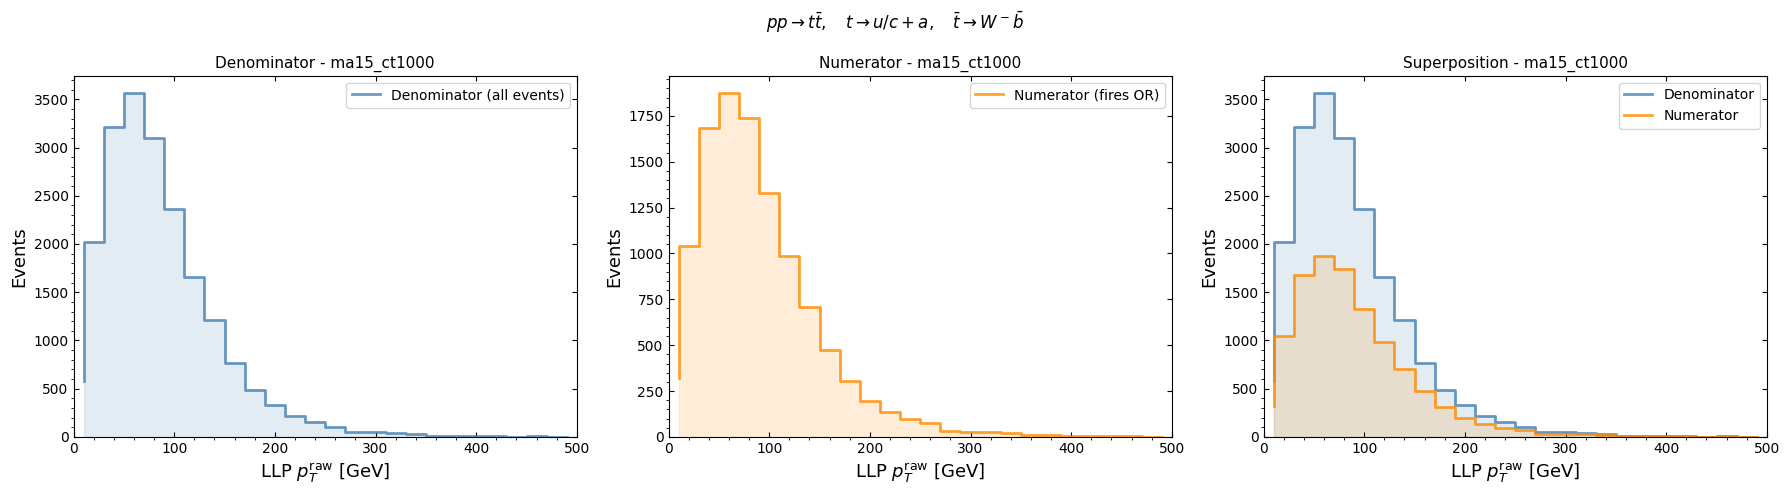

Figure saved:num_denom_vs_pt_raw_ma15_ct1000.png


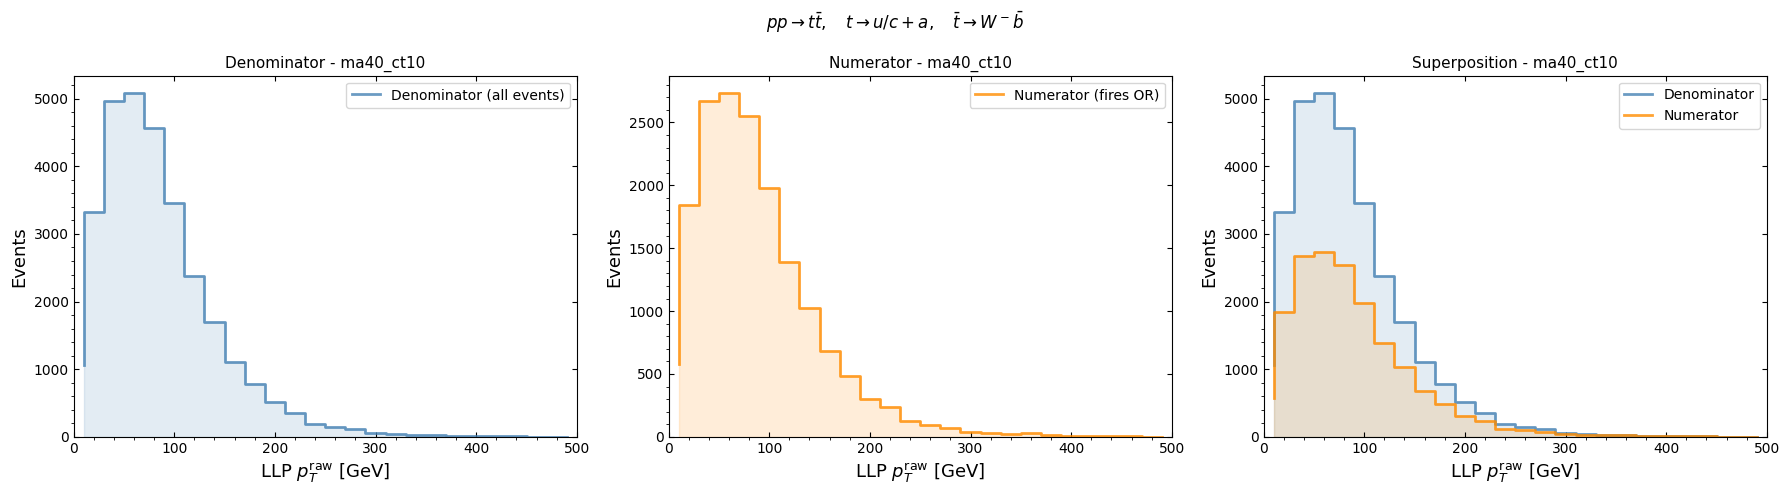

Figure saved:num_denom_vs_pt_raw_ma40_ct10.png


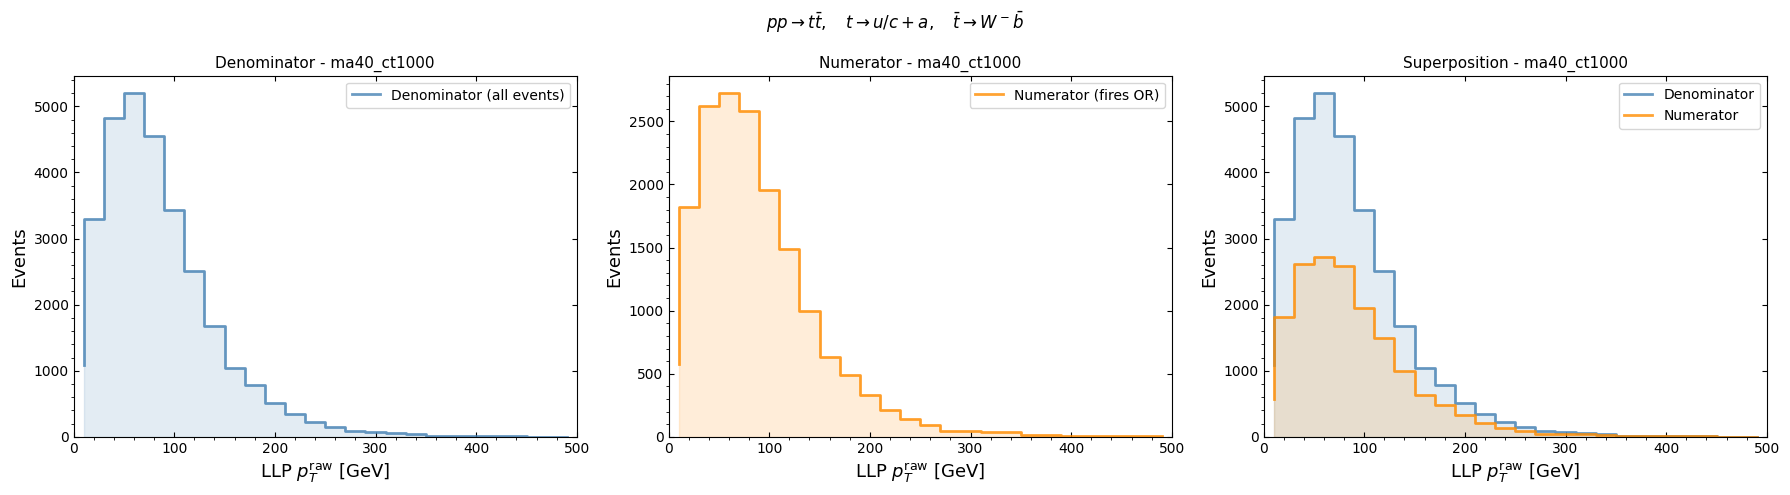

Figure saved:num_denom_vs_pt_raw_ma40_ct1000.png


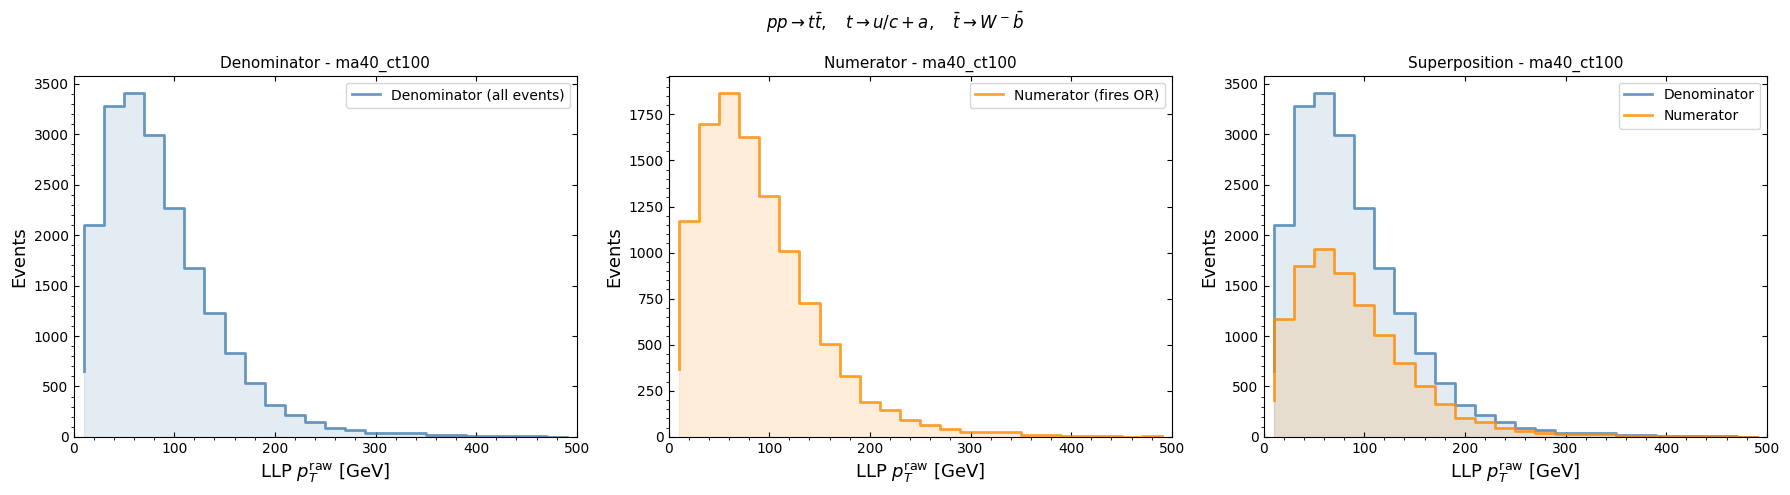

Figure saved:num_denom_vs_pt_raw_ma40_ct100.png


In [ ]:
# This function plots the numerator and denominator of the OR efficiency as a function of the raw pT of the ALP for each benchmark point. 
# It creates a figure with three subplots: one for the denominator, one for the numerator, and one for their superposition. The plots are saved as PNG files.
def plot_num_denom_vs_pt_raw(dfs, trigger_kwargs_dict, pt_raw_bins, ctau_map):
    """
    Trace le numérateur et dénominateur de l'efficacité OR
    en fonction du pT brut de l'ALP.
    """
    centers = 0.5 * (pt_raw_bins[:-1] + pt_raw_bins[1:])

    for nom in dfs.keys():
        df_tmp = dfs[nom]
        trigger_kwargs = trigger_kwargs_dict[nom]
        ma, ctau = ctau_map[nom]

        trig_all = (trigger_kwargs["triggers_calratio"] +
                    trigger_kwargs["triggers_calratiormbib"] +
                    trigger_kwargs["triggers_calratiovar"] +
                    trigger_kwargs["triggers_lhmedium"] +
                    trigger_kwargs["triggers_lhtight"] +
                    trigger_kwargs["triggers_lhloose"] +
                    trigger_kwargs["triggers_etcut"] +
                    trigger_kwargs["triggers_iloose"] +
                    trigger_kwargs["triggers_ivarmedium"] +
                    trigger_kwargs["triggers_0eta105"] +
                    trigger_kwargs["triggers_muon40"] +
                    trigger_kwargs["triggers_muon50"])
        trig_all = [t for t in trig_all if t in df_tmp.columns]

        fires_or = df_tmp[trig_all].any(axis=1)

        
        h_total,_ = np.histogram(df_tmp["pt_alp_raw"], bins=pt_raw_bins)
        h_pass,_ = np.histogram(df_tmp.loc[fires_or, "pt_alp_raw"], bins=pt_raw_bins)

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.patch.set_facecolor("white")
        for ax in axes:
            ax.set_facecolor("white")

        title = (rf"$ pp \to t\bar{{t}}, \quad t \to u/c + a, \quad \bar{{t}} \to W^-\bar{{b}}$")
           
        # Dénominateur
        axes[0].step(centers, h_total, color="steelblue",
                     linewidth=2, alpha=0.8, label="Denominator (all events)")
        axes[0].fill_between(centers, 0, h_total,
                             step="pre", color="steelblue", alpha=0.15)
        axes[0].set_xlabel(r"LLP $p_T^{\rm raw}$ [GeV]", fontsize=13)
        axes[0].set_ylabel("Events", fontsize=13)
        axes[0].set_xlim(pt_raw_bins[0], pt_raw_bins[-1])
        axes[0].set_ylim(0)
        axes[0].set_title(f"Denominator - {nom}", fontsize=11)
        axes[0].legend(fontsize=10)
        axes[0].minorticks_on()
        axes[0].tick_params(direction="in", top=True, right=True)

        # Numérateur
        axes[1].step(centers, h_pass, color="darkorange",
                     linewidth=2, alpha=0.8, label="Numerator (fires OR)")
        axes[1].fill_between(centers, 0, h_pass,
                             step="pre", color="darkorange", alpha=0.15)
        axes[1].set_xlabel(r"LLP $p_T^{\rm raw}$ [GeV]", fontsize=13)
        axes[1].set_ylabel("Events", fontsize=13)
        axes[1].set_xlim(pt_raw_bins[0], pt_raw_bins[-1])
        axes[1].set_ylim(0)
        axes[1].set_title(f"Numerator - {nom}", fontsize=11)
        axes[1].legend(fontsize=10)
        axes[1].minorticks_on()
        axes[1].tick_params(direction="in", top=True, right=True)

        # Superposition
        axes[2].step(centers, h_total, color="steelblue",
                     linewidth=2, alpha=0.8, label="Denominator")
        axes[2].fill_between(centers, 0, h_total,
                             step="pre", color="steelblue", alpha=0.15)
        axes[2].step(centers, h_pass, color="darkorange",
                     linewidth=2, alpha=0.8, label="Numerator")
        axes[2].fill_between(centers, 0, h_pass,
                             step="pre", color="darkorange", alpha=0.15)
        axes[2].set_xlabel(r"LLP $p_T^{\rm raw}$ [GeV]", fontsize=13)
        axes[2].set_ylabel("Events", fontsize=13)
        axes[2].set_xlim(pt_raw_bins[0], pt_raw_bins[-1])
        axes[2].set_ylim(0)
        axes[2].set_title(f"Superposition - {nom}", fontsize=11)
        axes[2].legend(fontsize=10)
        axes[2].minorticks_on()
        axes[2].tick_params(direction="in", top=True, right=True)

        plt.suptitle(title, fontsize=12)
        plt.tight_layout()
        fname= f"num_denom_vs_pt_raw_{nom}.png"
        plt.savefig(fname, dpi=300, bbox_inches="tight", facecolor="white")
        plt.show()
        print(f"Figure saved:{fname}")

plot_num_denom_vs_pt_raw(dfs, trigger_kwargs_dict, pt_raw_bins, ctau_map)

# Bins 

In [33]:
def print_bin_details(dfs, trigger_kwargs_dict, pt_raw_bins, ctau_map, ma):
    """
    Affiche le détail de chaque bin (N_total, N_pass, eff)
    pour tous les points (ma, ctau) d'une masse donnée,
    sans aucun masquage statistique.
    """
    centers = 0.5 * (pt_raw_bins[:-1] + pt_raw_bins[1:])

    points = {k: v for k, v in ctau_map.items() if v[0] == ma}
    noms= sorted(points.keys(), key=lambda k: ctau_map[k][1])

    for nom in noms:
        df_tmp = dfs[nom]
        trigger_kwargs = trigger_kwargs_dict[nom]
        ctau = ctau_map[nom][1]

        trig_all = (trigger_kwargs["triggers_calratio"] +
                    trigger_kwargs["triggers_calratiormbib"] +
                    trigger_kwargs["triggers_calratiovar"] +
                    trigger_kwargs["triggers_lhmedium"] +
                    trigger_kwargs["triggers_lhtight"] +
                    trigger_kwargs["triggers_lhloose"] +
                    trigger_kwargs["triggers_etcut"] +
                    trigger_kwargs["triggers_iloose"] +
                    trigger_kwargs["triggers_ivarmedium"] +
                    trigger_kwargs["triggers_0eta105"] +
                    trigger_kwargs["triggers_muon40"] +
                    trigger_kwargs["triggers_muon50"])
        trig_all = [t for t in trig_all if t in df_tmp.columns]

        fires_or = df_tmp[trig_all].any(axis=1)

        h_total,_ = np.histogram(df_tmp["pt_alp_raw"], bins=pt_raw_bins)
        h_pass,_ = np.histogram(df_tmp.loc[fires_or, "pt_alp_raw"], bins=pt_raw_bins)

        print(f"\n=== {nom} (ma={ma} GeV, ctau={ctau} mm) ===")
        print(f"{'pT [GeV]':>10} {'N_total':>10} {'N_pass':>10} {'eff':>10}")
        for c, n_tot, n_pass in zip(centers, h_total, h_pass):
            if n_tot > 0:  
                eff = n_pass / n_tot
                print(f"{c:>10.0f} {n_tot:>10} {n_pass:>10} {eff:>10.3f}")


# Appel pour ma=15
print_bin_details(dfs, trigger_kwargs_dict, pt_raw_bins, ctau_map, ma=15)

# Appel pour ma=40
print_bin_details(dfs, trigger_kwargs_dict, pt_raw_bins, ctau_map, ma=40)


=== ma15_ct1 (ma=15 GeV, ctau=1 mm) ===
  pT [GeV]    N_total     N_pass        eff
        10        910        505      0.555
        30       2979       1639      0.550
        50       4995       2711      0.543
        70       5210       2840      0.545
        90       4616       2587      0.560
       110       3542       2017      0.569
       130       2560       1519      0.593
       150       1701       1023      0.601
       170       1135        698      0.615
       190        742        471      0.635
       210        495        312      0.630
       230        344        212      0.616
       250        239        153      0.640
       270        156         99      0.635
       290         96         65      0.677
       310         78         49      0.628
       330         48         34      0.708
       350         30         19      0.633
       370         29         19      0.655
       390         30         21      0.700
       410          7          4   

# Each trigger familly 

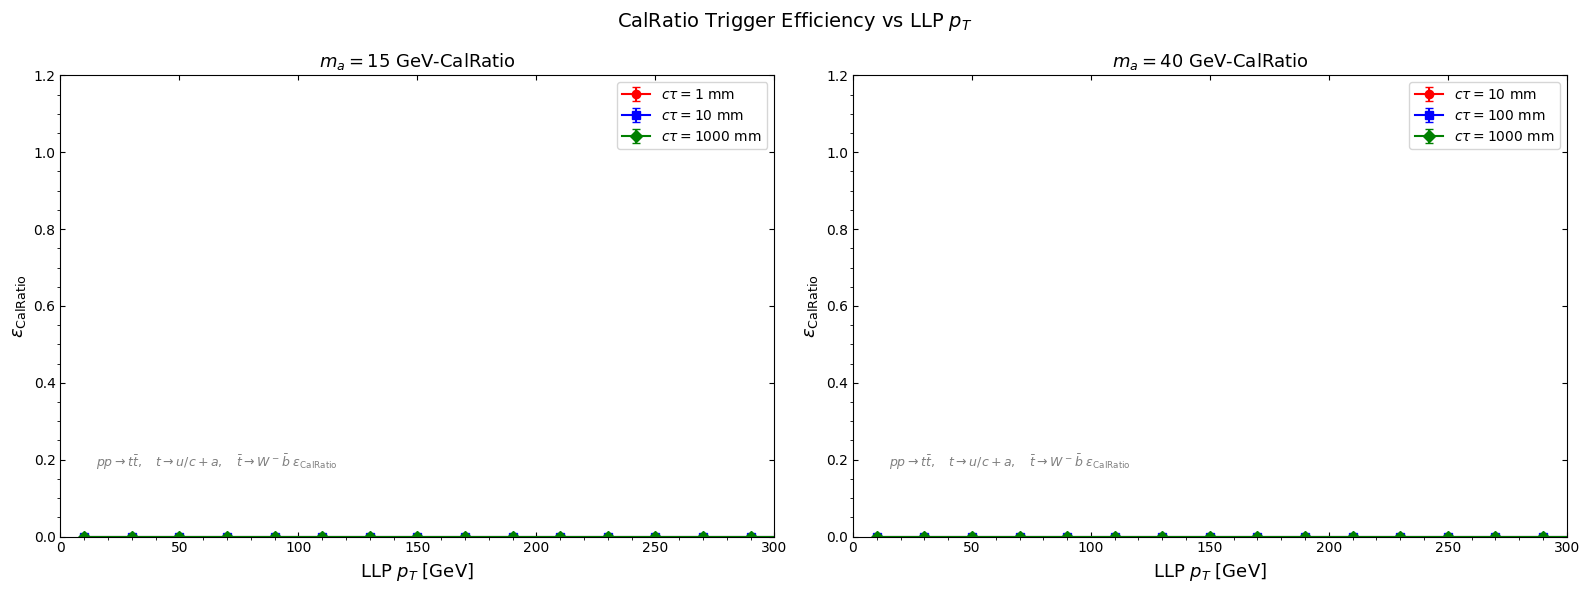

Figure saved: eff_calratio_vs_pt_raw.png


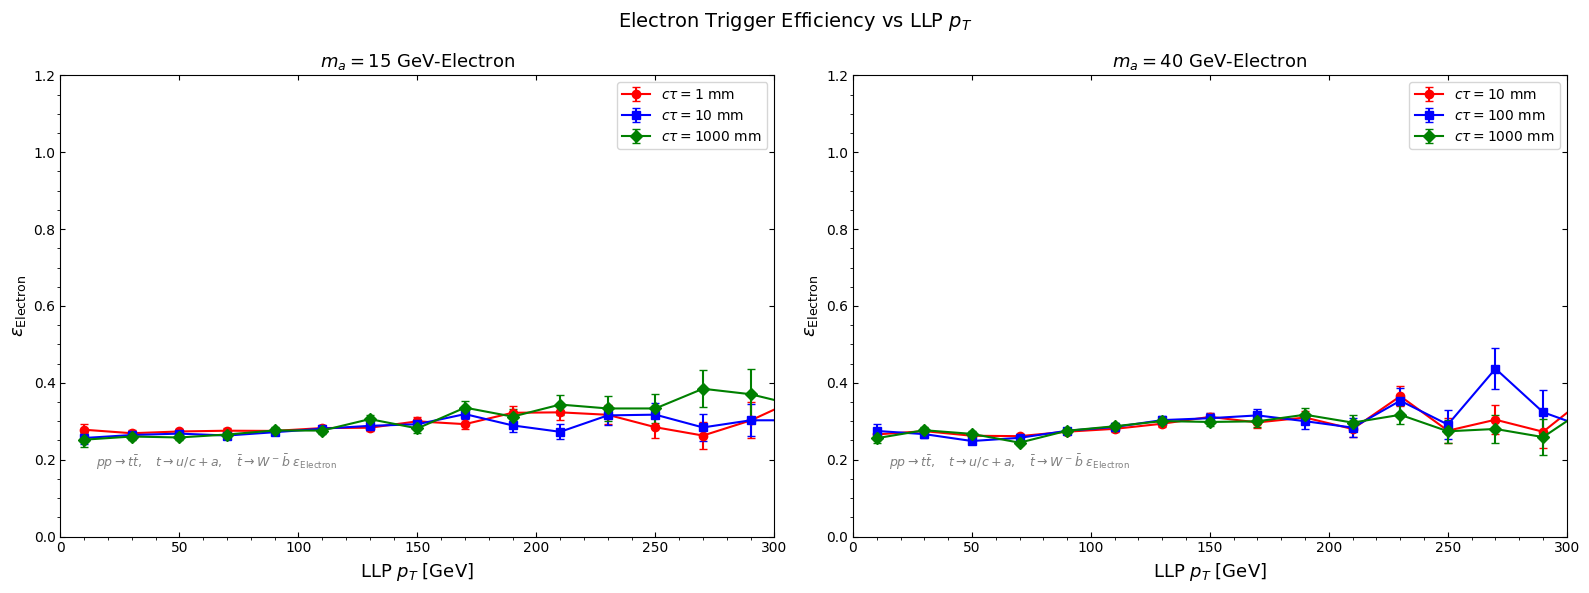

Figure saved: eff_electron_vs_pt_raw.png


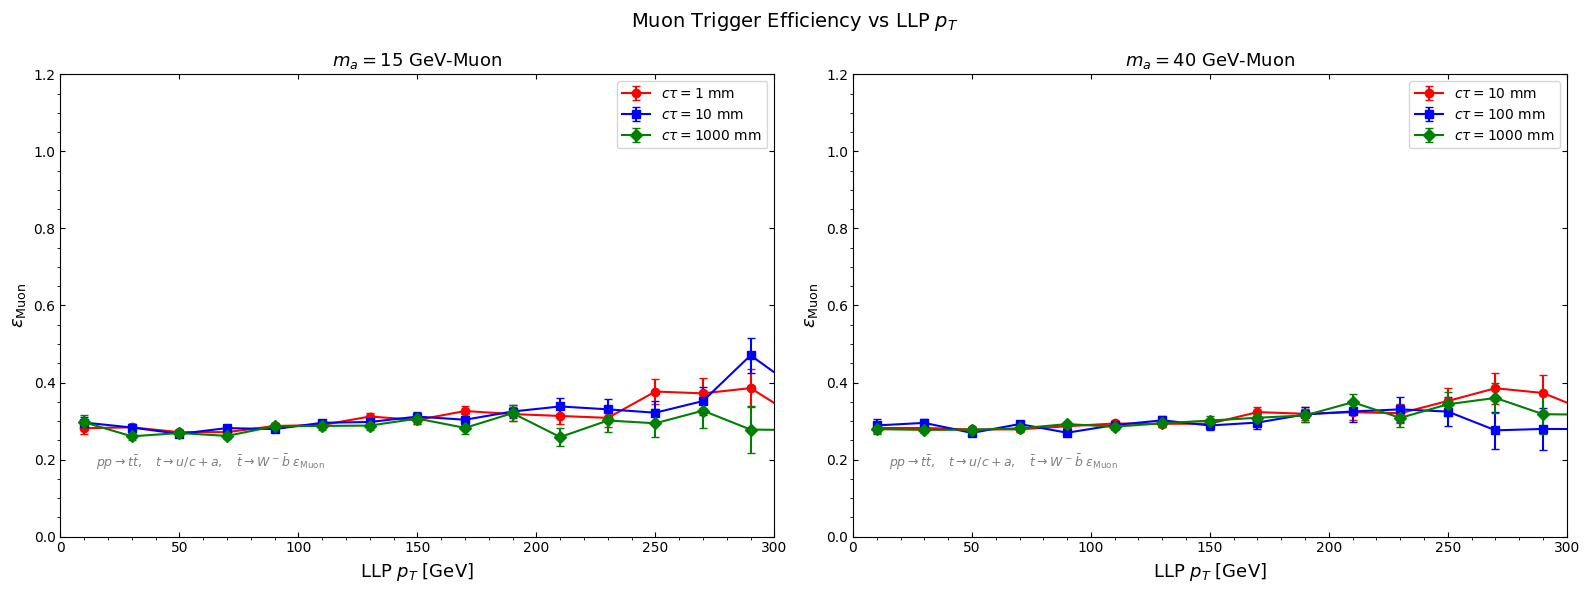

Figure saved: eff_muon_vs_pt_raw.png


In [34]:


def plot_eff_par_famille_vs_pt(dfs, trigger_kwargs_dict, pt_raw_bins, ctau_map):
    """
    Trace l'efficacité de chaque famille (CalRatio, Electron, Muon)
    en fonction du pT brut de l'ALP - un plot par famille,
    avec ma=15 et ma=40 côte à côte, et les ctau superposés.
    """
    centers = 0.5 * (pt_raw_bins[:-1] + pt_raw_bins[1:])
    colors = ["red", "blue", "green", "orange", "purple", "black"]
    markers = ["o", "s", "D", "^", "v", "X"]

    familles = {
        "CalRatio": lambda kw: (kw["triggers_calratio"] +
                                  kw["triggers_calratiormbib"] +
                                  kw["triggers_calratiovar"]),
        "Electron": lambda kw: (kw["triggers_lhmedium"] +
                                  kw["triggers_lhtight"] +
                                  kw["triggers_lhloose"] +
                                  kw["triggers_etcut"]),
        "Muon" : lambda kw: (kw["triggers_iloose"] +
                                  kw["triggers_ivarmedium"] +
                                  kw["triggers_0eta105"] +
                                  kw["triggers_muon40"] +
                                  kw["triggers_muon50"]),
    }

    for famille_name, get_trig_list in familles.items():

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        fig.patch.set_facecolor("white")

        for ma, ax in zip([15, 40], axes):
            ax.set_facecolor("white")

            points = {k: v for k, v in ctau_map.items() if v[0] == ma}
            noms = sorted(points.keys(), key=lambda k: ctau_map[k][1])

            for i, nom in enumerate(noms):
                df_tmp = dfs[nom]
                trigger_kwargs = trigger_kwargs_dict[nom]
                ctau = ctau_map[nom][1]

                trig_list = [t for t in get_trig_list(trigger_kwargs)
                            if t in df_tmp.columns]
                if len(trig_list) == 0:
                    continue

                fires = df_tmp[trig_list].any(axis=1)

                h_total,_ = np.histogram(df_tmp["pt_alp_raw"], bins=pt_raw_bins)
                h_pass,_ = np.histogram(df_tmp.loc[fires, "pt_alp_raw"], bins=pt_raw_bins)

                eff = np.divide(h_pass, h_total,
                                out=np.zeros_like(h_total, dtype=float),
                                where=h_total > 0)
                err = np.sqrt(np.divide(eff * (1 - eff), h_total,
                                        out=np.zeros_like(eff),
                                        where=h_total > 0))

                eff = np.where(h_total <= 5, np.nan, eff)
                err = np.where(h_total <= 5, np.nan, err)

                ax.errorbar(centers, eff, yerr=err,
                            marker=markers[i % len(markers)],
                            linestyle="-", color=colors[i % len(colors)],
                            capsize=3, linewidth=1.5, markersize=6,
                            label=rf"$c\tau = {ctau}$ mm")

            ax.set_xlabel(r"LLP $p_T$ [GeV]", fontsize=13)
            ax.set_ylabel(rf"$\varepsilon_{{\text{{{famille_name}}}}}$", fontsize=13)
            ax.set_ylim(0, 1.2)
            ax.set_xlim(0, 300)
            ax.set_title(rf"$m_a = {ma}\ \mathrm{{GeV}}$-{famille_name}", fontsize=13)
            ax.legend(fontsize=10, loc="upper right")
            ax.minorticks_on()
            ax.tick_params(direction="in", top=True, right=True)
            ax.text(0.05, 0.15, rf"$ pp \to t\bar{{t}}, \quad t \to u/c + a, \quad \bar{{t}} \to W^-\bar{{b}}$"
                    rf" $\varepsilon_{{\text{{{famille_name}}}}}$",
        transform=ax.transAxes, fontsize=9, color="gray")

        plt.suptitle(rf"{famille_name} Trigger Efficiency vs LLP $p_T$",
                     fontsize=14)
        plt.tight_layout()
        fname = f"eff_{famille_name.lower()}_vs_pt_raw.png"
        plt.savefig(fname, dpi=300, bbox_inches="tight", facecolor="white")
        plt.show()
        print(f"Figure saved: {fname}")

plot_eff_par_famille_vs_pt(dfs, trigger_kwargs_dict, pt_raw_bins, ctau_map)

In [35]:
def add_atlas_labels(ax, signal_label="", ctau_label="",
                     loc=(0.05, 0.95)):
    x, y = loc
    ax.text(x, y, "ATLAS", transform=ax.transAxes,
            fontsize=14, fontweight="bold", style="italic",
            verticalalignment="top")
    ax.text(x + 0.13, y, "Simulation", transform=ax.transAxes,
            fontsize=13, verticalalignment="top")

    if signal_label:
        ax.text(x, y - 0.07, signal_label, transform=ax.transAxes,
                fontsize=11, verticalalignment="top")
    if ctau_label:
        ax.text(x, y - 0.14, ctau_label, transform=ax.transAxes,
                fontsize=11, verticalalignment="top")

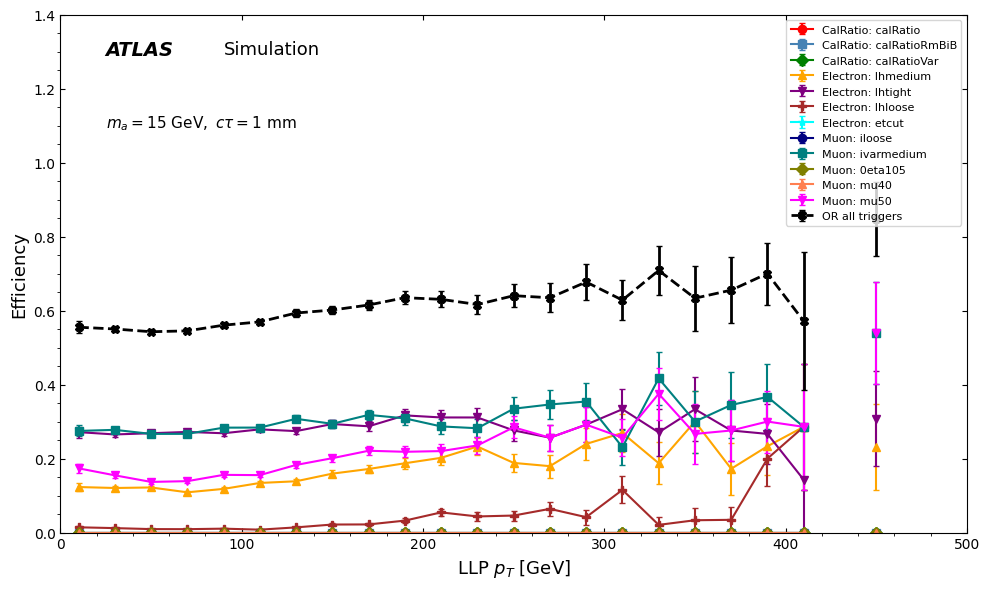

Figure saved:eff_all_triggers_ma15_ct1.png


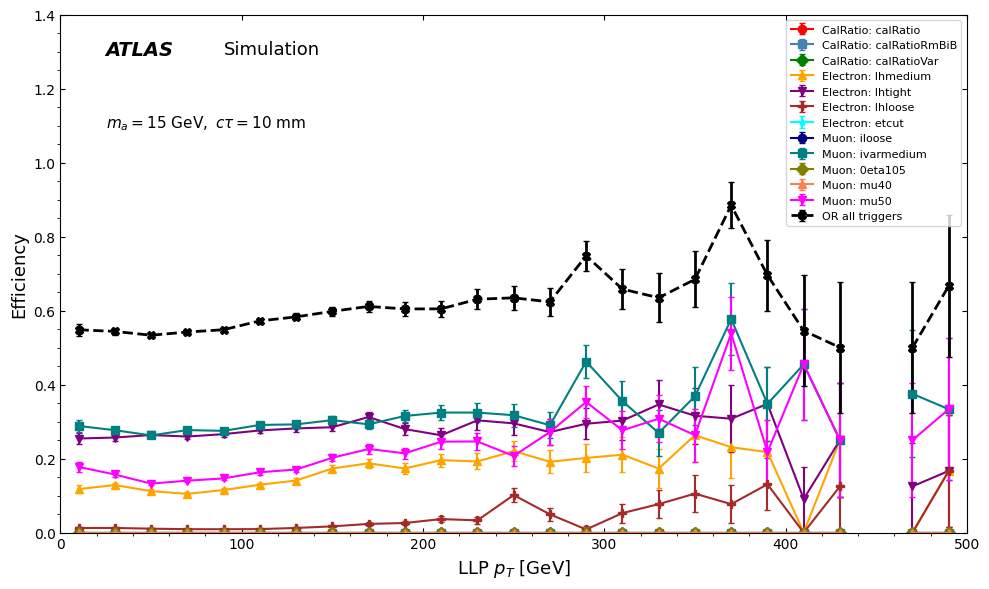

Figure saved:eff_all_triggers_ma15_ct10.png


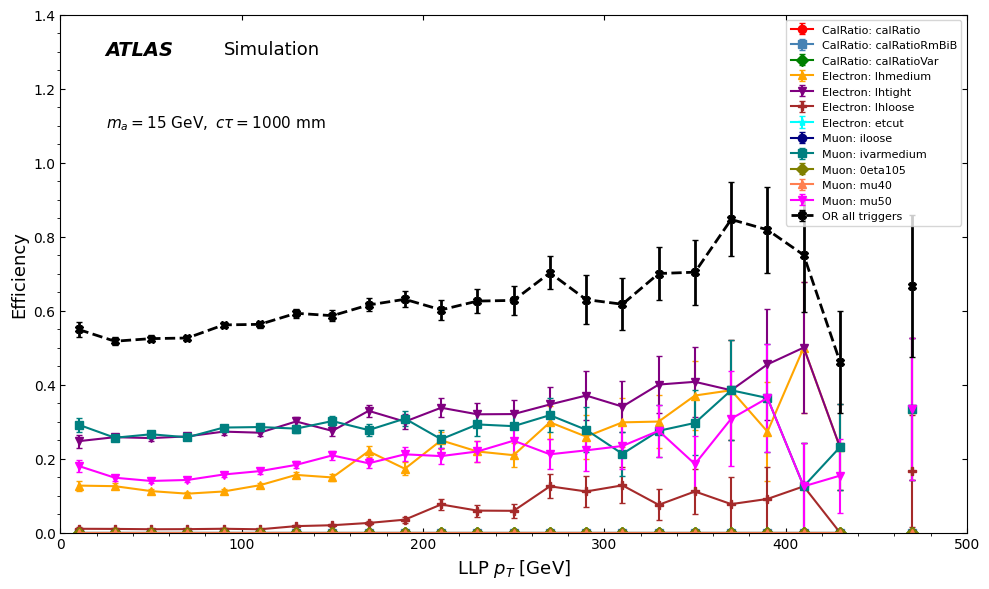

Figure saved:eff_all_triggers_ma15_ct1000.png


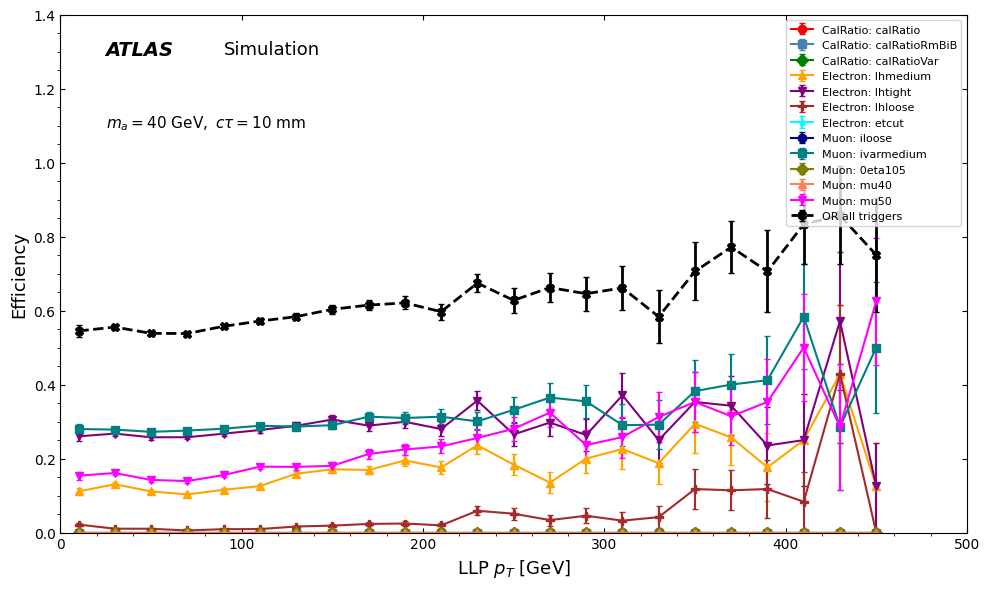

Figure saved:eff_all_triggers_ma40_ct10.png


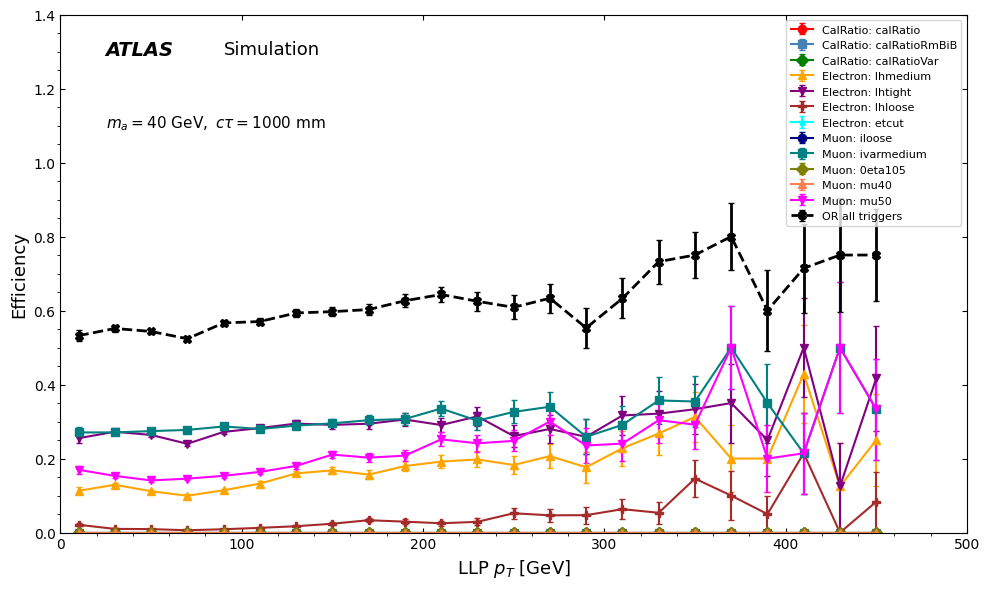

Figure saved:eff_all_triggers_ma40_ct1000.png


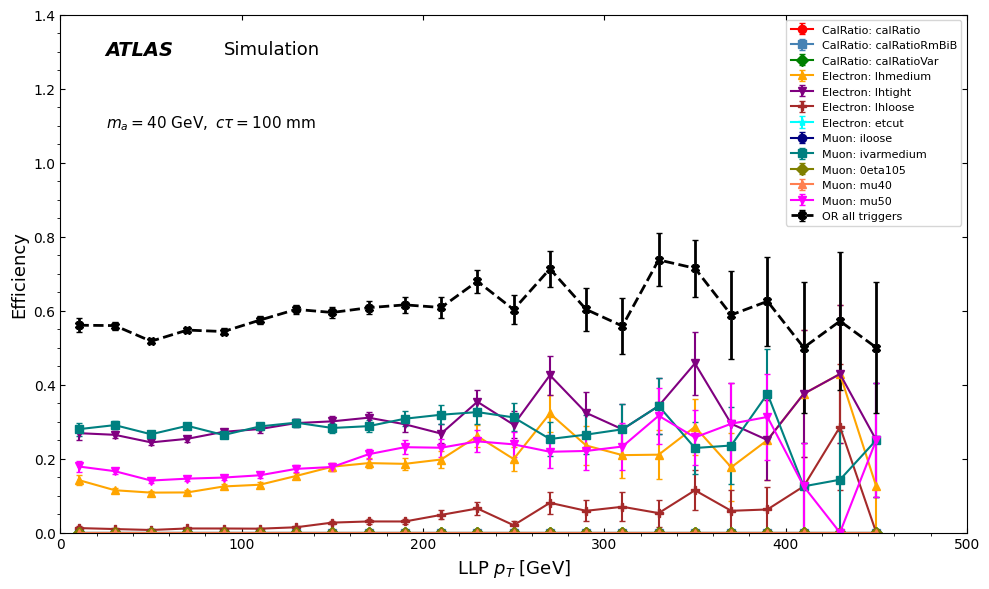

Figure saved:eff_all_triggers_ma40_ct100.png


In [36]:
def plot_all_triggers_atlas_style(df_tmp, trigger_kwargs, pt_raw_bins,
                                   ma, ctau,
                                   signal_label=None, ctau_label=None,
                                   output_file=None):
    centers = 0.5*(pt_raw_bins[:-1] + pt_raw_bins[1:])

    if signal_label is None:
        title = (rf"$ pp \to t\bar{{t}}, \quad t \to u/c + a, \quad \bar{{t}} \to W^-\bar{{b}}$")
    if ctau_label is None:
        ctau_label = rf"$m_a = {ma}\ \mathrm{{GeV}},\ c\tau = {ctau}\ \mathrm{{mm}}$"

    h_total,_ = np.histogram(df_tmp["pt_alp_raw"], bins=pt_raw_bins)

    def eff_trig(trig_list):
        trig_list = [t for t in trig_list if t in df_tmp.columns]
        if len(trig_list) == 0:
            return np.full(len(centers), np.nan), np.full(len(centers), np.nan)
        fires = df_tmp[trig_list].any(axis=1)
        h_pass, _ = np.histogram(df_tmp.loc[fires, "pt_alp_raw"], bins=pt_raw_bins)
        eff = np.divide(h_pass, h_total,
                        out=np.zeros_like(h_total, dtype=float),
                        where=h_total > 0)
        err = np.sqrt(np.divide(eff * (1 - eff), h_total,
                                out=np.zeros_like(eff),
                                where=h_total > 0))
        eff = np.where(h_total <= 5, np.nan, eff)
        err = np.where(h_total <= 5, np.nan, err)
        return eff, err

    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    # CalRatio family
    for label, trig_key, color, marker in [
        ("CalRatio: calRatio", [trigger_kwargs["triggers_calratio"][0]] if trigger_kwargs["triggers_calratio"] else [], "red", "o"),
        ("CalRatio: calRatioRmBiB", trigger_kwargs["triggers_calratiormbib"],"steelblue", "s"),
        ("CalRatio: calRatioVar", trigger_kwargs["triggers_calratiovar"],"green", "D"),
    ]:
        eff, err = eff_trig(trig_key)
        ax.errorbar(centers, eff, yerr=err, marker=marker, linestyle="-",
                    color=color, capsize=2, label=label)

    # Electron family
    for label, trig_key, color, marker in [
        ("Electron: lhmedium", trigger_kwargs["triggers_lhmedium"],"orange", "^"),
        ("Electron: lhtight", trigger_kwargs["triggers_lhtight"],"purple", "v"),
        ("Electron: lhloose", trigger_kwargs["triggers_lhloose"], "brown",  "P"),
        ("Electron: etcut", trigger_kwargs["triggers_etcut"],"cyan",   "*"),
    ]:
        eff, err = eff_trig(trig_key)
        ax.errorbar(centers, eff, yerr=err, marker=marker, linestyle="-",
                    color=color, capsize=2, label=label)

    # Muon family
    for label, trig_key, color, marker in [
        ("Muon: iloose", trigger_kwargs["triggers_iloose"],"navy", "o"),
        ("Muon: ivarmedium", trigger_kwargs["triggers_ivarmedium"], "teal","s"),
        ("Muon: 0eta105",trigger_kwargs["triggers_0eta105"],"olive","D"),
        ("Muon: mu40",trigger_kwargs["triggers_muon40"],"coral","^"),
        ("Muon: mu50", trigger_kwargs["triggers_muon50"],"magenta","v"),
    ]: 
        eff, err = eff_trig(trig_key)
        ax.errorbar(centers, eff, yerr=err, marker=marker, linestyle="-",
                    color=color, capsize=2, label=label)

    # OR all triggers
    trig_all = (trigger_kwargs["triggers_calratio"] +
                trigger_kwargs["triggers_calratiormbib"] +
                trigger_kwargs["triggers_calratiovar"] +
                trigger_kwargs["triggers_lhmedium"] +
                trigger_kwargs["triggers_lhtight"] +
                trigger_kwargs["triggers_lhloose"] +
                trigger_kwargs["triggers_etcut"] +
                trigger_kwargs["triggers_iloose"] +
                trigger_kwargs["triggers_ivarmedium"] +
                trigger_kwargs["triggers_0eta105"] +
                trigger_kwargs["triggers_muon40"] +
                trigger_kwargs["triggers_muon50"])
    eff_or, err_or = eff_trig(trig_all)
    ax.errorbar(centers, eff_or, yerr=err_or, marker="X", linestyle="--",
                color="black", capsize=2, linewidth=2, label="OR all triggers")

    add_atlas_labels(ax, signal_label=signal_label, ctau_label=ctau_label)

    ax.set_xlabel(r"LLP $p_T$ [GeV]", fontsize=13)
    ax.set_ylabel("Efficiency", fontsize=13)
    ax.set_ylim(0,1.4)
    ax.set_xlim(0,500)
    ax.legend(fontsize=8, loc="upper right")
    ax.minorticks_on()
    ax.tick_params(direction="in", top=True, right=True)

    plt.tight_layout()
    if output_file is None:
        output_file = f"eff_all_triggers_ma{ma}_ct{ctau}.png"
    plt.savefig(output_file, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Figure saved:{output_file}")


# Appel pour chaque échantillon
for nom, df_tmp in dfs.items():
    ma, ctau = ctau_map[nom]
    plot_all_triggers_atlas_style(df_tmp, trigger_kwargs_dict[nom],
                                  pt_raw_bins, ma, ctau)